In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape


(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
print(df["sex"].unique())
print(df["smoker"].unique())
print(df["region"].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [10]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [11]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


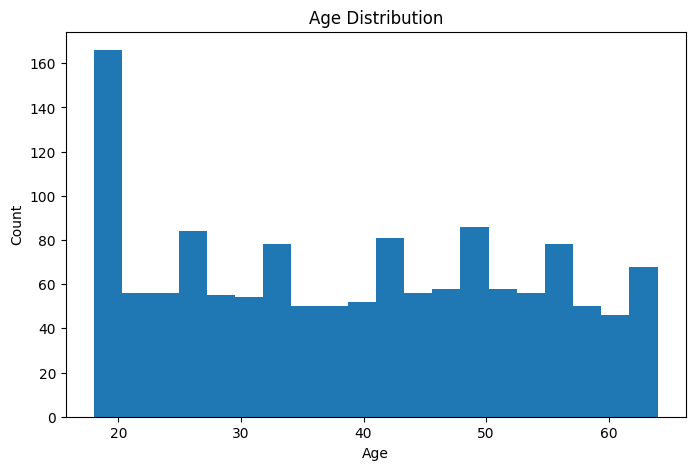

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

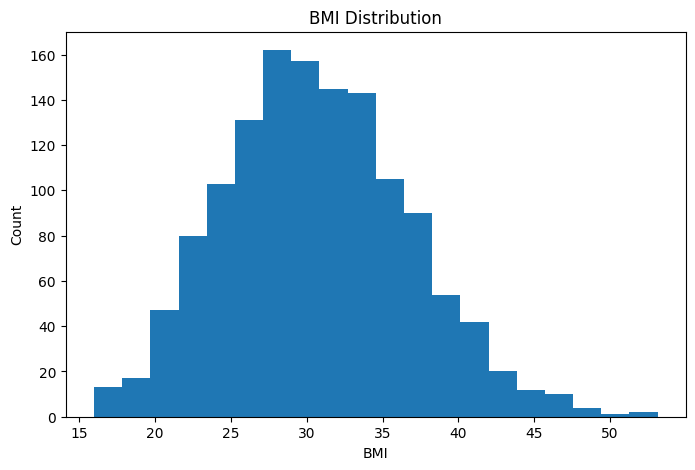

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

<Figure size 800x500 with 0 Axes>

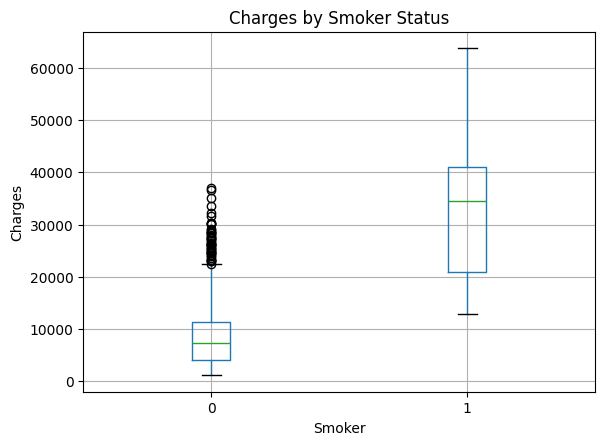

In [14]:
plt.figure(figsize=(8,5))
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoker Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

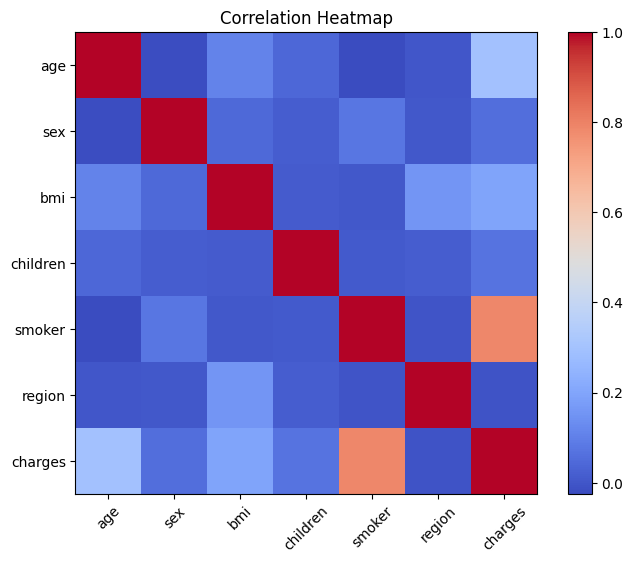

In [15]:
plt.figure(figsize=(8,6))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1070, 6)
Testing data: (268, 6)


In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [21]:
lr_pred = lr.predict(X_test)

In [22]:
print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))


Linear Regression Results
MAE : 4186.508898366436
MSE : 33635210.43117845
RMSE: 5799.5870914383595
R2 Score: 0.7833463107364536


In [23]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [24]:
dt_pred = dt.predict(X_test)

In [25]:
print("Decision Tree Results")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree Results
MAE : 3070.0831479067165
MSE : 47349691.413584165
RMSE: 6881.111204855228
R2 Score: 0.6950075471882797


In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
rf_pred = rf.predict(X_test)

In [28]:
print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 2518.4756348106666
MSE : 20898625.73754565
RMSE: 4571.501475177018
R2 Score: 0.8653861739369313


In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4186.508898,5799.587091,0.783346
1,Decision Tree,3070.083148,6881.111205,0.695008
2,Random Forest,2518.475635,4571.501475,0.865386


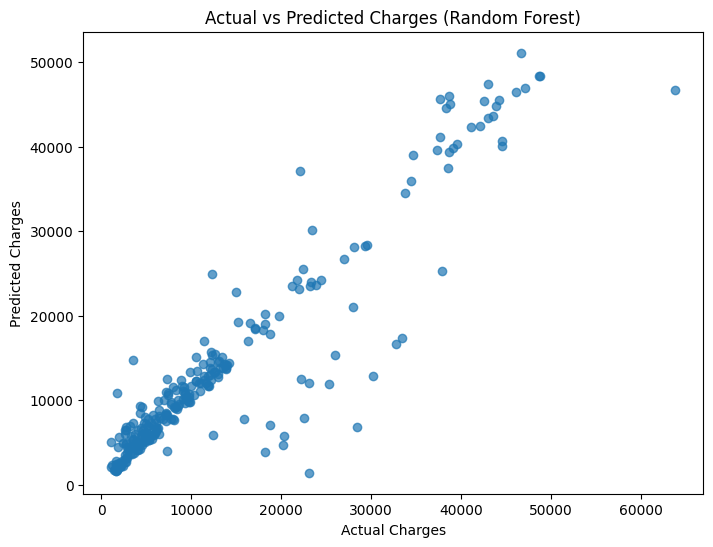

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Random Forest)")
plt.show()

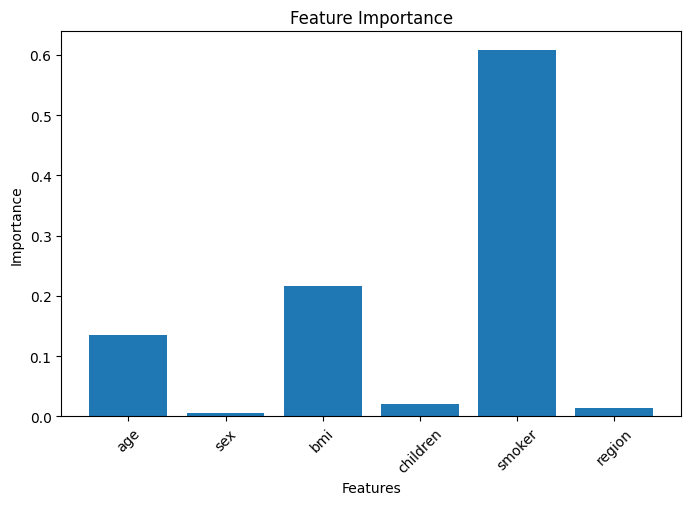

In [31]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

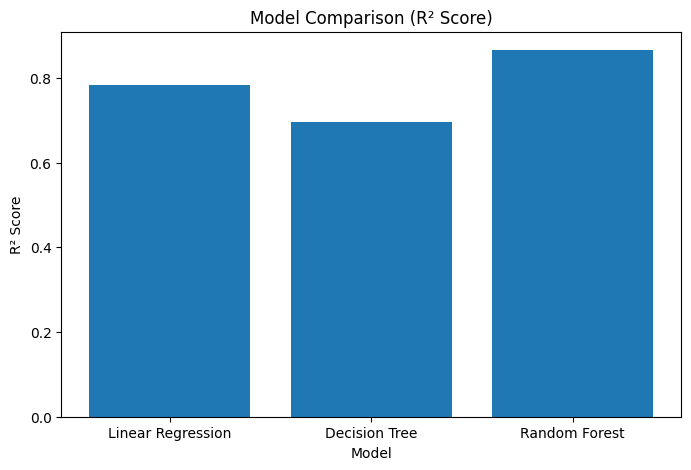

In [32]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

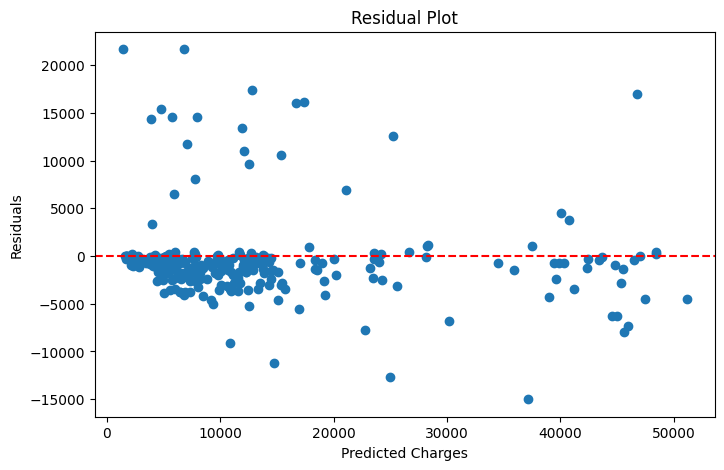

In [33]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
plt.scatter(rf_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

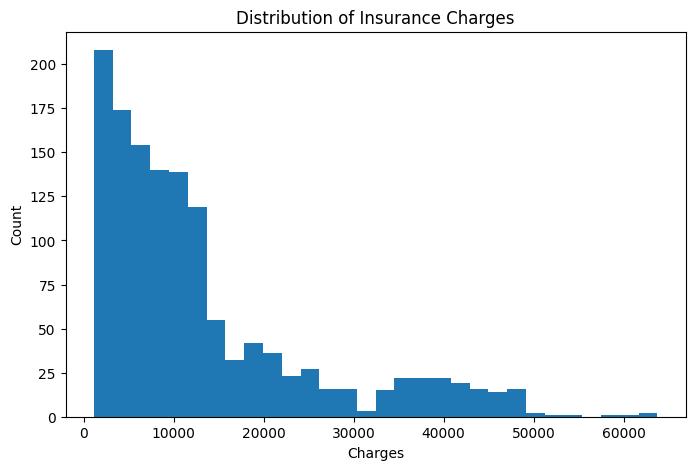

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.savefig("distribution_charges.png")
plt.show()

In [35]:
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4186.508898,5799.587091,0.783346
1,Decision Tree,3070.083148,6881.111205,0.695008
2,Random Forest,2518.475635,4571.501475,0.865386


In [36]:
results = results.sort_values(by="R2 Score", ascending=False)
results

,Model,MAE,RMSE,R2 Score
2,Random Forest,2518.475635,4571.501475,0.865386
0,Linear Regression,4186.508898,5799.587091,0.783346
1,Decision Tree,3070.083148,6881.111205,0.695008


In [37]:
new_customer = pd.DataFrame({
    "age": [25],
    "sex": [1],
    "bmi": [28.5],
    "children": [0],
    "smoker": [0],
    "region": [2]
})

new_customer_scaled = scaler.transform(new_customer)

predicted_charge = rf.predict(new_customer_scaled)

print("Predicted Insurance Charge:", predicted_charge[0])

Predicted Insurance Charge: 2530.180055999999


In [38]:
import joblib

In [39]:
joblib.dump(lr, "linear_regression.pkl")

['linear_regression.pkl']

In [40]:
joblib.dump(dt, "decision_tree.pkl")

['decision_tree.pkl']

In [41]:
joblib.dump(rf, "random_forest.pkl")

['random_forest.pkl']